            name    gu      totpop  stores  bins  demand   binN  urgency
0         Songpa   송파구  751378.502    1233   191   0.702  0.128    0.574
1           Mapo   마포구  474025.820    1840   270   0.661  0.212    0.449
2         Seocho   서초구  584179.349    1151   252   0.544  0.193    0.352
3       Gangdong   강동구  512385.431     595    96   0.322  0.028    0.295
4           Jung    중구  320112.433    1338   176   0.389  0.112    0.277
5   Yeongdeungpo  영등포구  520483.532     871   202   0.411  0.140    0.271
6      Seongdong   성동구  352775.761     678   142   0.220  0.076    0.143
7          Nowon   노원구  475444.340     374   156   0.227  0.091    0.136
8         Jongno   종로구  304752.272    1345   330   0.379  0.275    0.104
9        Gangseo   강서구  550059.535     686   343   0.379  0.289    0.090
10        Gwanak   관악구  472213.254     573   256   0.284  0.197    0.087
11    Dongdaemun  동대문구  365138.338     569   191   0.197  0.128    0.069
12      Seongbuk   성북구  426469.949     572   247   

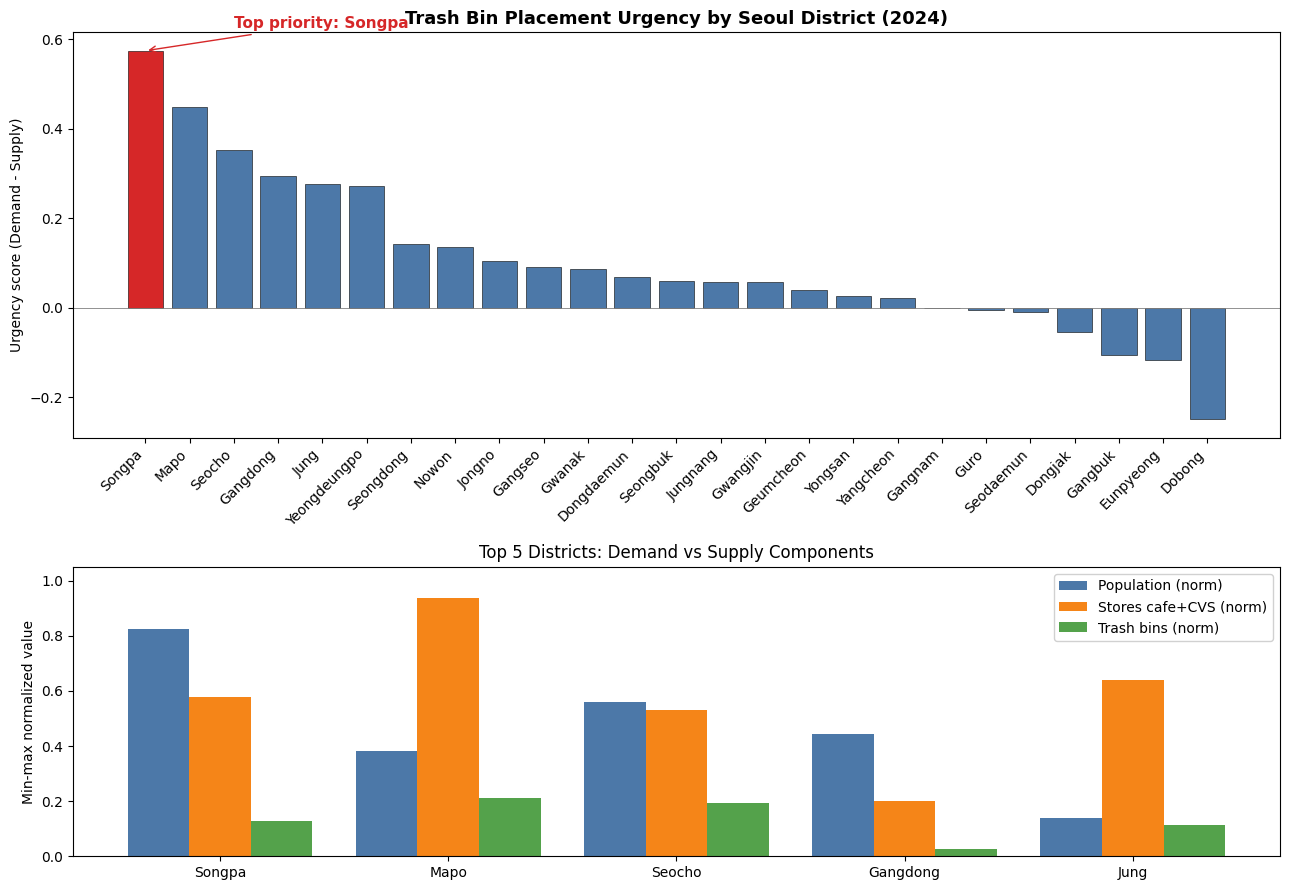

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

!pip install dbfread
from dbfread import DBF

P = '/content/'

# ---------- 1. Trash bins ----------
bins = pd.read_excel(P + '서울특별시 년도별 자치구별 가로쓰레기통 설치현황(2024.12.).xlsx')
bins = bins[bins['자치구'] != '합계'][['자치구', '2024년']].rename(
    columns={'자치구': 'gu', '2024년': 'bins'})

# ---------- 2. Floating population ----------
loc = pd.read_csv(P + 'LOCAL_PEOPLE_GU_2024.csv',
                  usecols=['adstrd_code_se', 'tot_lvpop_co'])
loc = loc.groupby('adstrd_code_se')['tot_lvpop_co'].mean().reset_index()
loc.columns = ['code', 'local']

def readfor(path, enc):
    d = pd.read_csv(path, usecols=['자치구코드', '총생활인구수'], encoding=enc)
    return d.groupby('자치구코드')['총생활인구수'].mean().reset_index()

lf = readfor(P + 'LONG_FOREGNER_GU_2024.csv', 'cp949')
lf.columns = ['code', 'longf']
tf = readfor(P + 'TEMP_FOREIGNER_GU_2024.csv', 'utf-8-sig')
tf.columns = ['code', 'tempf']

pop = loc.merge(lf, on='code').merge(tf, on='code')
pop['totpop'] = pop['local'] + pop['longf'] + pop['tempf']

# ---------- 3. Stores: cafe + CVS, 2024 Q4 ----------
st = pd.read_csv(P + '서울시 상권분석서비스(점포-상권)_2024년.csv', encoding='cp949')
st = st[(st['기준_년분기_코드'] == 20244) &
        (st['서비스_업종_코드'].isin(['CS100010', 'CS300002']))]
st = st.groupby('상권_코드')['점포_수'].sum().reset_index()
st.columns = ['trdar', 'stores']
st['trdar'] = st['trdar'].astype(str)

# ---------- 4. 상권 -> 자치구 mapping (DBF) ----------
tab = DBF(P + '서울시 상권분석서비스(영역-상권).dbf', encoding='utf-8')
mp = pd.DataFrame([{'trdar': r['TRDAR_CD'],
                    'code': int(r['SIGNGU_CD']),
                    'gu':   r['SIGNGU_CD_']} for r in tab])

stgu = st.merge(mp, on='trdar')
stgu = stgu.groupby(['code', 'gu'])['stores'].sum().reset_index()

# ---------- 5. Combine ----------
df = stgu.merge(pop, on='code').merge(bins, on='gu')

roman = {'종로구':'Jongno','중구':'Jung','용산구':'Yongsan','성동구':'Seongdong',
         '광진구':'Gwangjin','동대문구':'Dongdaemun','중랑구':'Jungnang',
         '성북구':'Seongbuk','강북구':'Gangbuk','도봉구':'Dobong','노원구':'Nowon',
         '은평구':'Eunpyeong','서대문구':'Seodaemun','마포구':'Mapo',
         '양천구':'Yangcheon','강서구':'Gangseo','구로구':'Guro','금천구':'Geumcheon',
         '영등포구':'Yeongdeungpo','동작구':'Dongjak','관악구':'Gwanak',
         '서초구':'Seocho','강남구':'Gangnam','송파구':'Songpa','강동구':'Gangdong'}
df['name'] = df['gu'].map(roman)

mm = lambda s: (s - s.min()) / (s.max() - s.min())
df['popN'] = mm(df['totpop'])
df['stN']  = mm(df['stores'])
df['binN'] = mm(df['bins'])
df['demand']  = 0.5 * df['popN'] + 0.5 * df['stN']
df['urgency'] = df['demand'] - df['binN']

df = df.sort_values('urgency', ascending=False).reset_index(drop=True)

print(df[['name','gu','totpop','stores','bins','demand','binN','urgency']]
      .round(3).to_string())

top = df.iloc[0]
print(f"\n>>> Most urgent district: {top['name']} ({top['gu']})")
print(f"    Avg floating population : {top['totpop']:>14,.0f}")
print(f"    Cafes + CVS (Q4 2024)   : {top['stores']:>14,.0f}")
print(f"    Trash bins (Dec 2024)   : {top['bins']:>14,.0f}")
print(f"    Urgency score           : {top['urgency']:>14.3f}")

# ---------- 6. Visualization ----------
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                         gridspec_kw={'height_ratios': [1.4, 1]})

# (a) Urgency ranking
ax = axes[0]
clr = ['#d62728' if i == 0 else '#4c78a8' for i in range(len(df))]
ax.bar(df['name'], df['urgency'], color=clr, edgecolor='black', linewidth=0.4)
ax.axhline(0, color='gray', lw=0.6)
ax.set_ylabel('Urgency score (Demand - Supply)')
ax.set_title('Trash Bin Placement Urgency by Seoul District (2024)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='x', labelrotation=45)
for lab in ax.get_xticklabels():
    lab.set_ha('right')
ax.annotate(f"Top priority: {top['name']}",
            xy=(0, top['urgency']), xytext=(2, top['urgency'] + 0.05),
            fontsize=11, color='#d62728', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d62728'))

# (b) Top-5 component breakdown
ax = axes[1]
top5 = df.head(5)
x = np.arange(len(top5))
w = 0.27
ax.bar(x - w, top5['popN'], w, label='Population (norm)', color='#4c78a8')
ax.bar(x,     top5['stN'],  w, label='Stores cafe+CVS (norm)', color='#f58518')
ax.bar(x + w, top5['binN'], w, label='Trash bins (norm)', color='#54a24b')
ax.set_xticks(x)
ax.set_xticklabels(top5['name'])
ax.set_ylabel('Min-max normalized value')
ax.set_title('Top 5 Districts: Demand vs Supply Components', fontsize=12)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_ylim(0, 1.05)

plt.tight_layout()
out = '/mnt/user-data/outputs/urgency.png'
os.makedirs(os.path.dirname(out), exist_ok=True)
plt.savefig(out, dpi=140, bbox_inches='tight')
print(f"\nFigure saved: {out}")